# WM-811K Wafer Dataset Exploration
This notebook loads the `LSWMD.pkl` dataset, processes the nested fields, and visualizes the dataset.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import pandas.core.indexes
sys.modules['pandas.indexes'] = pandas.core.indexes
try:
    import pandas.core.indexes.base
    sys.modules['pandas.indexes.base'] = pandas.core.indexes.base
except ImportError:
    pass

# Load Dataset
with open('LSWMD.pkl', 'rb') as f:
    df = pickle.load(f, encoding='latin1')
df.info()

/var/folders/m_/4r8l9_rn6jng5pdc6lth0yhr0000gn/T/ipykernel_6007/488859903.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [2]:
# Clean up nested arrays/lists in the columns
# The elements are sometimes numpy arrays inside lists, or numpy arrays containing strings
def extract_val(x):
    if type(x) == list or type(x).__name__ == 'ndarray':
        if len(x) > 0:
            if type(x[0]) == list or type(x[0]).__name__ == 'ndarray':
                if len(x[0]) > 0:
                    return x[0][0]
                return None
            return x[0]
        return None
    return x
df['failureType'] = df['failureType'].apply(extract_val)
df['trianTestLabel'] = df['trianTestLabel'].apply(extract_val)

df['failureType'].value_counts()

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

## Basic Statistics: Let's look at the basic statistics: Train/Test split, Die Size, and Lot Names.

In [3]:
# Basic statistics of the dataset
print("Train/Test Distribution:")
print(df['trianTestLabel'].value_counts(dropna=False))

print("\nDie Size Statistics:")
print(df['dieSize'].describe())

print("\nTop 10 Lot Names by frequency:")
print(df['lotName'].value_counts().head(10))


Train/Test Distribution:
trianTestLabel
NaN         638507
Test        118595
Training     54355
Name: count, dtype: int64

Die Size Statistics:
count    811457.000000
mean       1840.998585
std        2254.987374
min           3.000000
25%         710.000000
50%         953.000000
75%        1902.000000
max       48099.000000
Name: dieSize, dtype: float64

Top 10 Lot Names by frequency:
lotName
lot1     25
lot2     25
lot3     25
lot4     25
lot5     25
lot6     25
lot7     25
lot8     25
lot9     25
lot10    25
Name: count, dtype: int64


## Failure Type Distribution

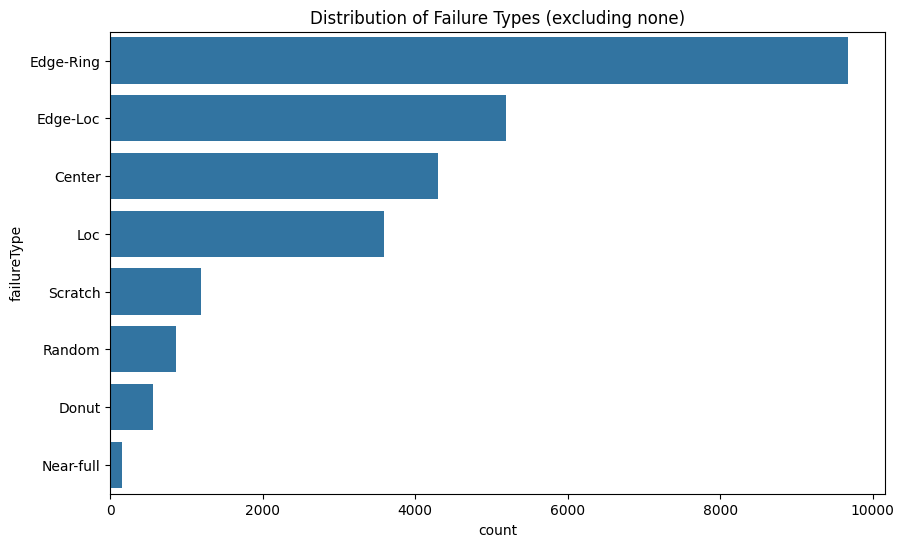

In [4]:
# Plot distribution of failure types
plt.figure(figsize=(10, 6))
sns.countplot(data=df[df['failureType'] != 'none'], y='failureType', order=df[df['failureType'] != 'none']['failureType'].value_counts().index)
plt.title('Distribution of Failure Types (excluding none)')
plt.show()

## Sample Visualizations

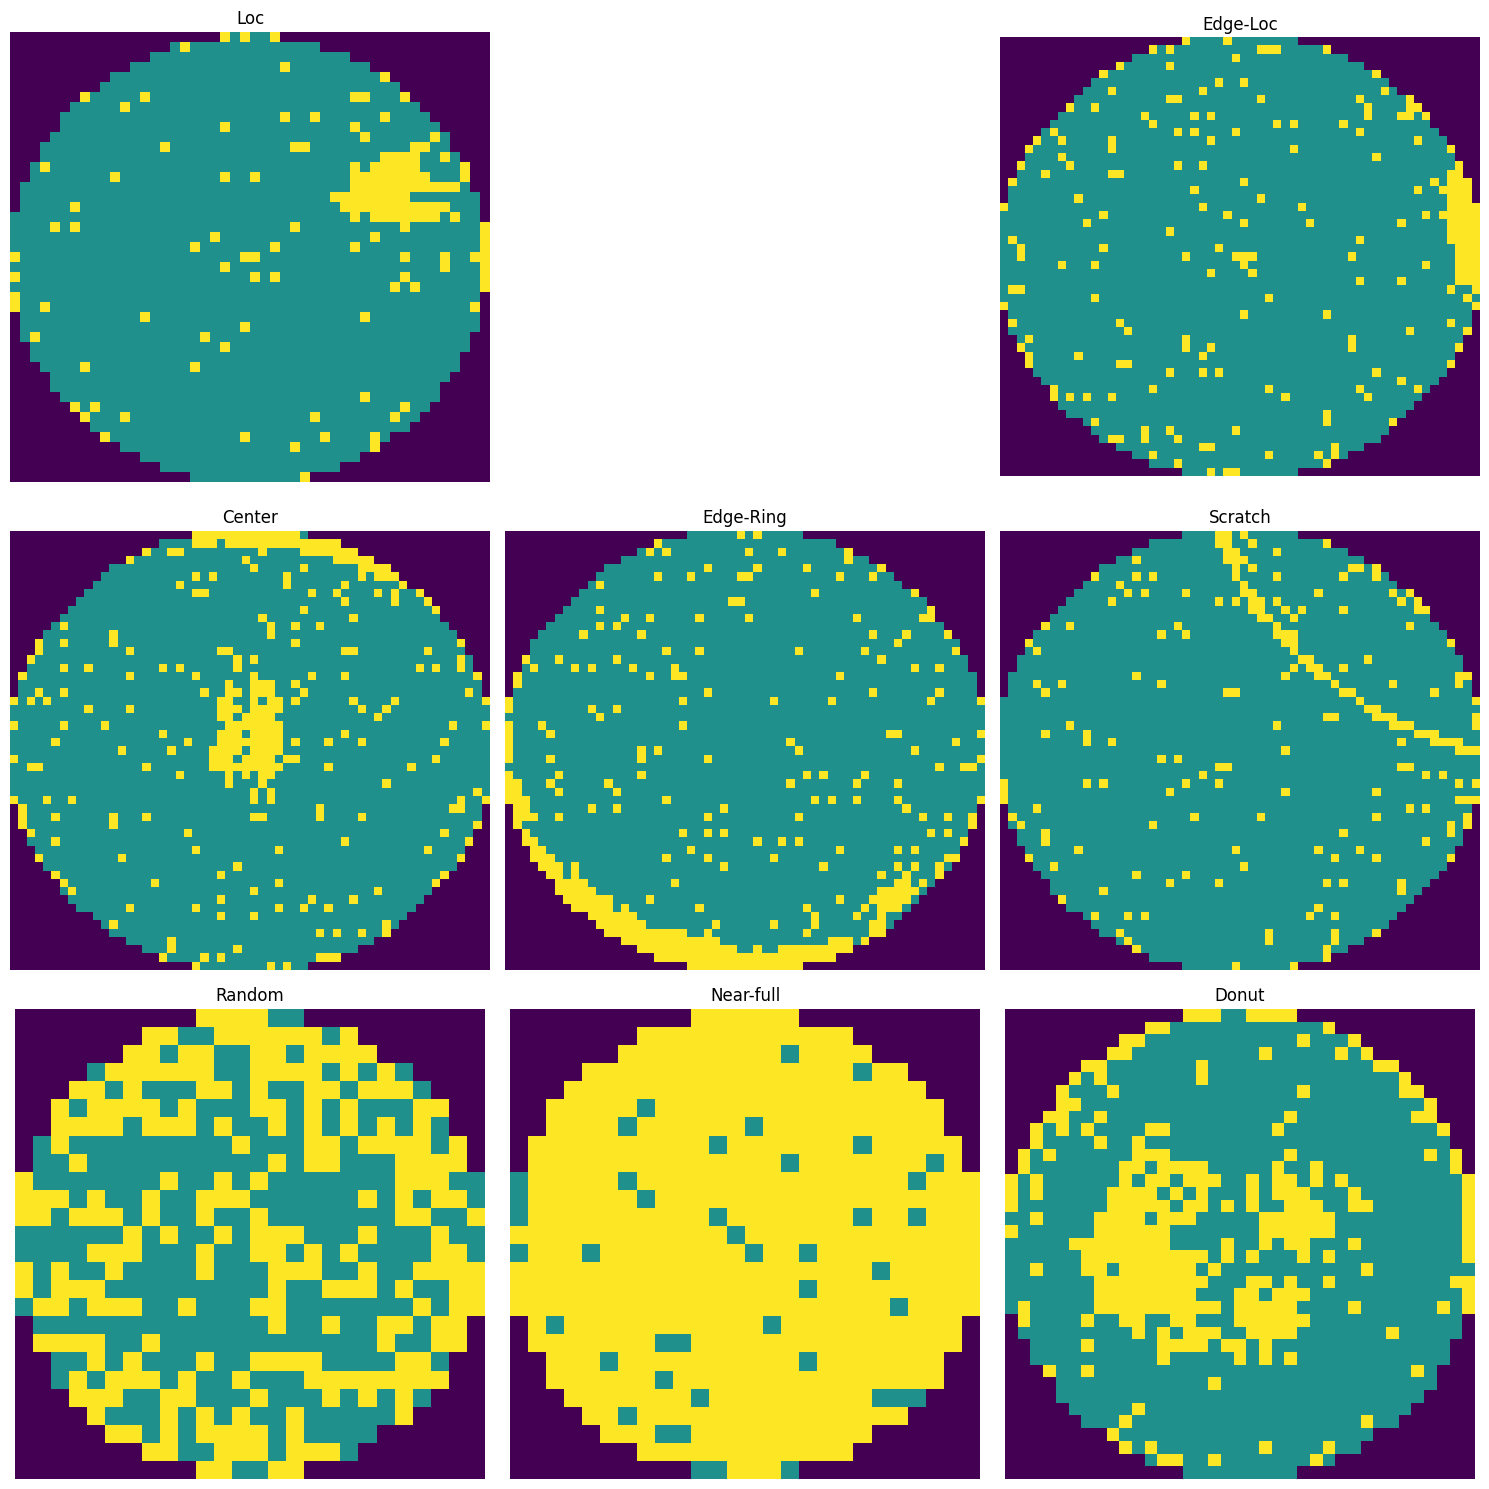

In [5]:
# Visualize a few examples of failure types
failure_types = df[df['failureType'] != 'none']['failureType'].unique()
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

# get sample per failure type
for i, ftype in enumerate([f for f in failure_types if f is not None][:9]):
    samples = df[df['failureType'] == ftype]
    if len(samples) > 0:
        sample = samples.iloc[0]
        axes[i].imshow(sample['waferMap'], cmap='viridis')
        axes[i].set_title(ftype)
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()